In [1]:
from utils import load_nested_results

results = load_nested_results("results_all")

In [2]:
del results["23_mammography"]

In [63]:
import numpy as np
from scipy.interpolate import interp1d
from itertools import combinations


def mae_sim(pdp_i, pdp_j, sub):
    sims = []
    for feat in pdp_i.keys():
        curve_i = np.array(pdp_i[feat][sub])
        curve_j = np.array(pdp_j[feat][sub])

        # Center curves to isolate the marginal effect from global model bias differences
        curve_i -= np.mean(curve_i)
        curve_j -= np.mean(curve_j)

        dist = np.mean(np.abs(curve_i - curve_j))

        # Convert unbounded MAE distance to a [0, 1] similarity score
        sims.append(1 / (1 + dist))

    return np.nanmean(sims)


def pdp_corr(pdp_i, pdp_j, sub) -> float:
    corrs = []
    for feat in pdp_i.keys():
        tmp_pdp_i = pdp_i[feat][sub]
        tmp_pdp_j = pdp_j[feat][sub]

        if len(tmp_pdp_i.shape) >= 2:
            tmp_pdp_i = tmp_pdp_i.flatten()

        if len(tmp_pdp_j.shape) >= 2:
            tmp_pdp_j = tmp_pdp_j.flatten()

        corrs.append(np.corrcoef(tmp_pdp_i.flatten(), tmp_pdp_j.flatten())[0, 1])
    return np.nanmean(corrs)


def compute_similarity_pearson(results_dict, xai, sub):
    return compute_pairwise_metric(results_dict, xai, sub, pdp_corr)


def compute_mae_sim(results_dict, xai, sub):
    return compute_pairwise_metric(results_dict, xai, sub, mae_sim)


def compute_pairwise_metric(results_dict, key, sub, metric_fn):
    """
    Generic function to compute pairwise similarity/distance matrices
    across models for a given metric and key (e.g., 'shapvalues', 'scores', 'predictions').
    """
    model_names = sorted(results_dict.keys() - {"ground_truth"})
    n_models = len(model_names)
    n_fold = len(results_dict[model_names[0]])

    matrix = np.eye(n_models, dtype=float)

    for i, j in combinations(range(n_models), 2):
        scores = []
        for f in range(n_fold):
            scores.append(
                metric_fn(
                    results_dict[model_names[i]][f][key],
                    results_dict[model_names[j]][f][key],
                    sub,
                )
            )

        matrix[i, j] = matrix[j, i] = np.nanmean(scores)

    return matrix, model_names

In [64]:
model_names = sorted(results.keys() - {"ground_truth"})
n_models = len(model_names)
n_fold = len(results[model_names[0]])


pdp_pearsons = []
pdp_maes = []
ale_pearsons = []
ale_maes = []
for dataset, v in results.items():
    pdp_pearson, names = compute_similarity_pearson(v, "pdp_values", "average")
    pdp_mae, _ = compute_mae_sim(v, "pdp_values", "average")
    ale_pearson, _ = compute_similarity_pearson(v, "ale_values", "ale_values")
    ale_mae, _ = compute_mae_sim(v, "ale_values", "ale_values")

    pdp_pearsons.append(pdp_pearson)
    pdp_maes.append(pdp_mae)
    ale_pearsons.append(ale_pearson)
    ale_maes.append(ale_mae)

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_4008/1524716619.py:18: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = sch.linkage(dist_matrix, method="average")


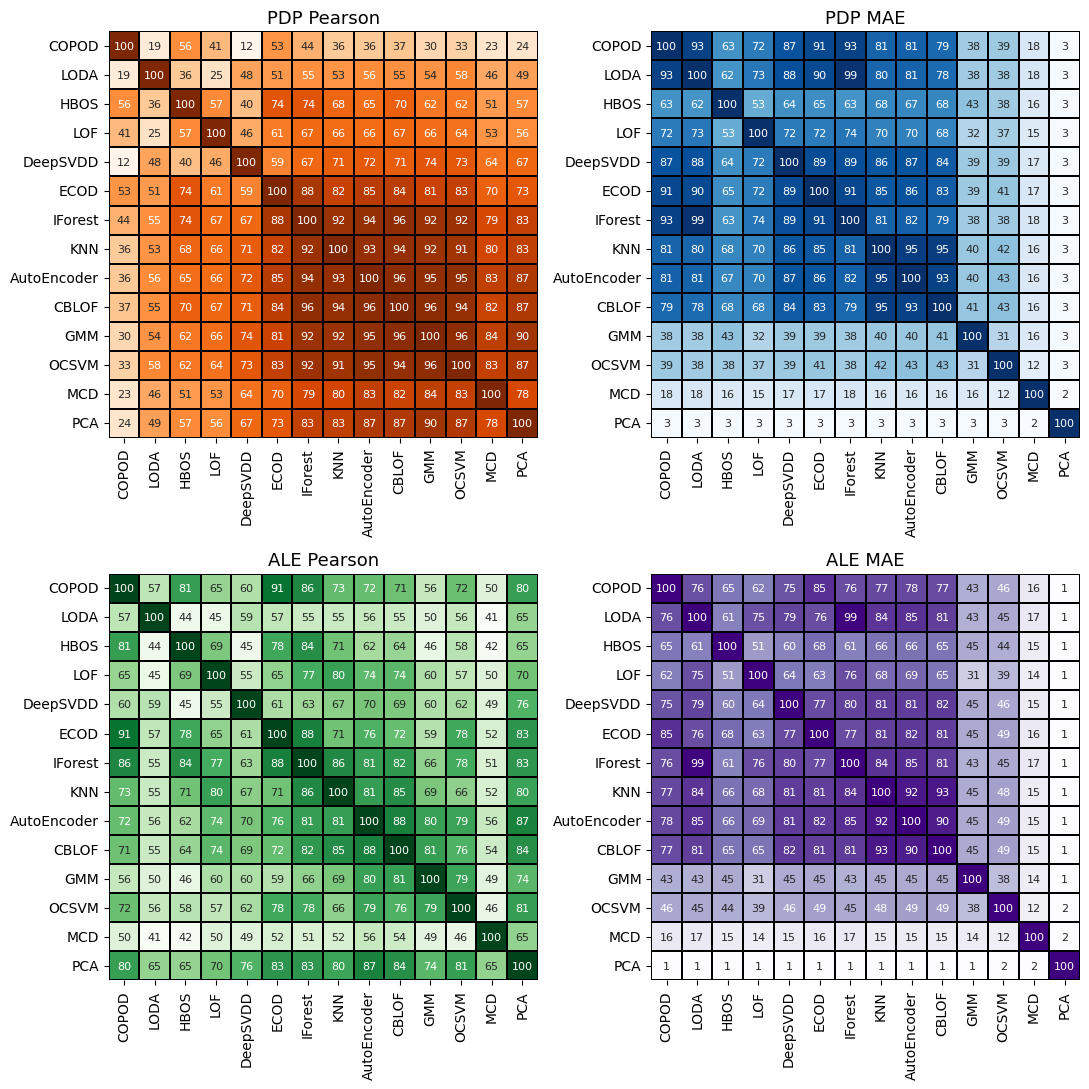

In [65]:
import pandas as pd
from utils import plot_heatmaps
import scipy.cluster.hierarchy as sch

all_matrices = {
    "PDP Pearson": pdp_pearsons,
    "PDP MAE": pdp_maes,
    "ALE Pearson": ale_pearsons,
    "ALE MAE": ale_maes,
}

df_dict = {}
for name, mat_list in all_matrices.items():
    mean_mat = np.nanmean(np.array(mat_list), axis=0)
    df_dict[name] = pd.DataFrame(mean_mat * 100, index=names, columns=names)

dist_matrix = 100 - df_dict["PDP Pearson"].values
linkage = sch.linkage(dist_matrix, method="average")
dendro = sch.dendrogram(linkage, no_plot=True)
ordered_labels = [df_dict["PDP Pearson"].index[i] for i in dendro["leaves"]]

for name in df_dict:
    df_dict[name] = df_dict[name].loc[ordered_labels, ordered_labels]


fig = plot_heatmaps(
    df_dict,
    figsize=(11, 11),
    colormaps=["Oranges", "Blues", "Greens", "Purples"],
)

# fig.savefig("matrices.eps", format="eps", bbox_inches="tight", pad_inches=0.1)

In [66]:
from skbio.stats.distance import mantel

matrices_dist = [1 - np.nanmean(m, axis=0) for m in all_matrices.values()]
names = list(all_matrices.keys())

n = len(matrices_dist)
mantel_corrs = np.zeros((n, n))
mantel_pvals = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        corr, pval, _ = mantel(matrices_dist[i], matrices_dist[j], permutations=10000)
        mantel_corrs[i, j] = mantel_corrs[j, i] = corr
        mantel_pvals[i, j] = mantel_pvals[j, i] = pval

df_corr = pd.DataFrame(mantel_corrs, index=names, columns=names)
df_pval = pd.DataFrame(mantel_pvals, index=names, columns=names)

print("Mantel correlation matrix:")
print(df_corr.round(2))
print("\n")
print("Mantel p-value matrix:")
print(df_pval.round(3))

Mantel correlation matrix:
             PDP Pearson  PDP MAE  ALE Pearson  ALE MAE
PDP Pearson         1.00    -0.16         0.45    -0.10
PDP MAE            -0.16     1.00         0.16     0.99
ALE Pearson         0.45     0.16         1.00     0.17
ALE MAE            -0.10     0.99         0.17     1.00


Mantel p-value matrix:
             PDP Pearson  PDP MAE  ALE Pearson  ALE MAE
PDP Pearson        0.000    0.554        0.044    0.722
PDP MAE            0.554    0.000        0.523    0.000
ALE Pearson        0.044    0.523        0.000    0.505
ALE MAE            0.722    0.000        0.505    0.000


<Axes: >

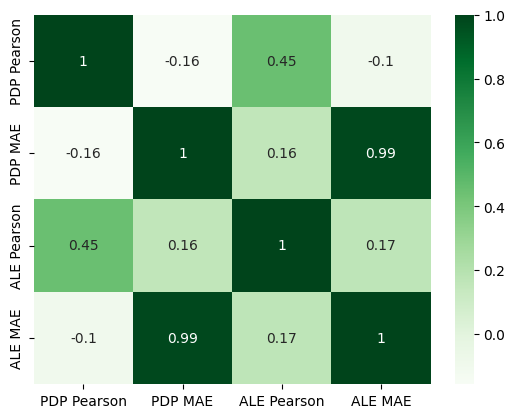

In [67]:
import seaborn as sns

sns.heatmap(df_corr, annot=True, cmap="Greens")